In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


In [2]:
def wind_field_star(wind_spec):
    return np.array(wind_spec["u_star"], dtype=float)

def odes_star(tau, y, Gamma, Lambda, wind_spec):
    x, y_, z, vx, vy, vz = y
    v = np.array([vx, vy, vz])
    u = wind_field_star(wind_spec)

    vrel = v - u
    speed = np.linalg.norm(vrel)

    dxdt = vx
    dydt = vy
    dzdt = vz

    dvxdt = -Lambda * speed * vrel[0]
    dvydt = -Lambda * speed * vrel[1]
    dvzdt = -Gamma - Lambda * speed * vrel[2]

    return [dxdt, dydt, dzdt, dvxdt, dvydt, dvzdt]


In [3]:
def hit_ground(tau, y):
    return y[2]

hit_ground.terminal = True
hit_ground.direction = -1


In [4]:
def initial_velocity(theta, phi):
    return np.array([
        np.cos(theta)*np.cos(phi),
        np.cos(theta)*np.sin(phi),
        np.sin(theta)
    ])


In [5]:
def simulate(theta, phi, Gamma, Lambda, wind_spec,
             z0_star=0.0, tau_max=30.0):

    y0 = np.zeros(6)
    y0[0:3] = [0.0, 0.0, z0_star]
    y0[3:6] = initial_velocity(theta, phi)

    sol = solve_ivp(
        lambda t, y: odes_star(t, y, Gamma, Lambda, wind_spec),
        (0, tau_max),
        y0,
        events=hit_ground,
        rtol=1e-4,
        atol=1e-6,
        max_step=0.05
    )

    if sol.status != 1:
        return None, None

    xL, yL = sol.y[0, -1], sol.y[1, -1]
    rL = np.hypot(xL, yL)
    psiL = np.arctan2(yL, xL)

    return sol, {"xL": xL, "yL": yL, "rL": rL, "psiL": psiL}


In [6]:
Gamma  = 0.12    # gravity strength
Lambda = 0.15    # drag strength (increased → less overshoot)
z0_star = 0.0


In [7]:
winds = [
    {"u_star": (0.0, 0.0, 0.0)},
    {"u_star": (0.05, 0.0, 0.0)},
    {"u_star": (0.10, 0.0, 0.0)},
    {"u_star": (0.15, 0.0, 0.0)},
]


In [8]:
theta = np.deg2rad(55)   # launch angle
phi   = 0.0             # launch direction


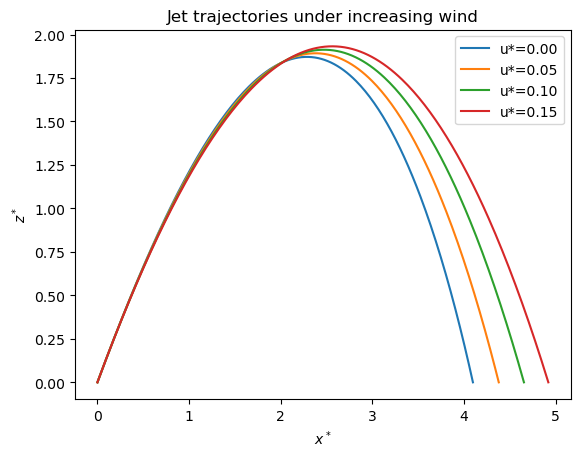

In [9]:
plt.figure()
for w in winds:
    sol, _ = simulate(theta, phi, Gamma, Lambda, w)
    if sol is not None:
        plt.plot(sol.y[0], sol.y[2],
                 label=f"u*={w['u_star'][0]:.2f}")

plt.xlabel(r"$x^*$")
plt.ylabel(r"$z^*$")
plt.title("Jet trajectories under increasing wind")
plt.legend()
plt.show()


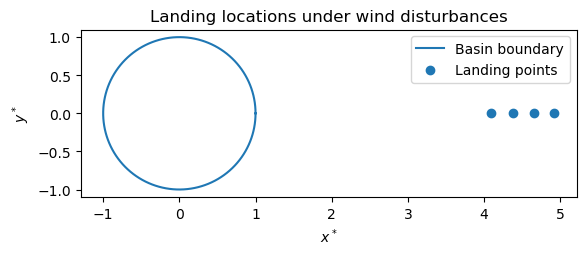

In [10]:
xs, ys = [], []

for w in winds:
    _, land = simulate(theta, phi, Gamma, Lambda, w)
    if land:
        xs.append(land["xL"])
        ys.append(land["yL"])

theta_circ = np.linspace(0, 2*np.pi, 400)
plt.figure()
plt.plot(np.cos(theta_circ), np.sin(theta_circ), label="Basin boundary")
plt.scatter(xs, ys, label="Landing points")
plt.gca().set_aspect("equal")
plt.xlabel(r"$x^*$")
plt.ylabel(r"$y^*$")
plt.title("Landing locations under wind disturbances")
plt.legend()
plt.show()


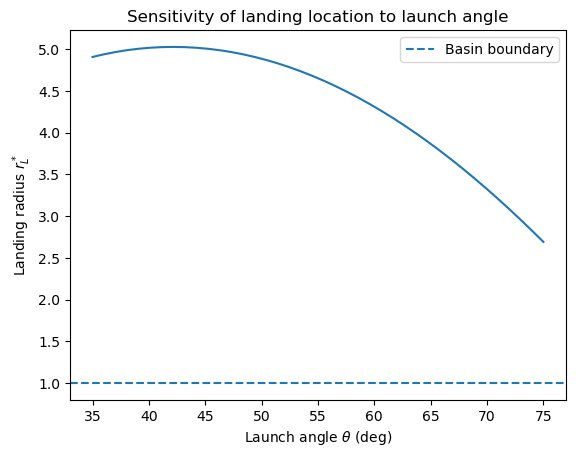

In [11]:
angles = np.deg2rad(np.linspace(35, 75, 40))
rvals = []

wind_fixed = {"u_star": (0.1, 0.0, 0.0)}

for th in angles:
    _, land = simulate(th, phi, Gamma, Lambda, wind_fixed)
    rvals.append(np.nan if land is None else land["rL"])

plt.figure()
plt.plot(np.rad2deg(angles), rvals)
plt.axhline(1.0, linestyle="--", label="Basin boundary")
plt.xlabel(r"Launch angle $\theta$ (deg)")
plt.ylabel(r"Landing radius $r_L^*$")
plt.title("Sensitivity of landing location to launch angle")
plt.legend()
plt.show()


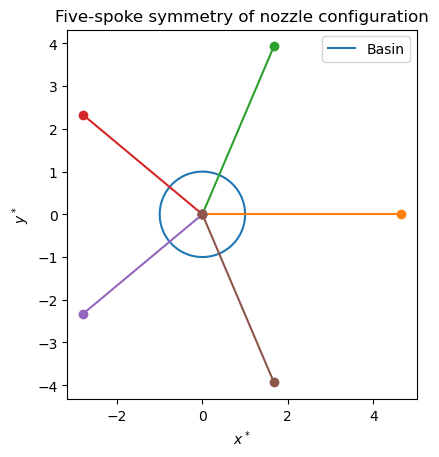

In [12]:
plt.figure()
plt.plot(np.cos(theta_circ), np.sin(theta_circ), label="Basin")

for i in range(5):
    phi_i = phi + i*(2*np.pi/5)
    _, land = simulate(theta, phi_i, Gamma, Lambda, wind_fixed)
    if land:
        plt.plot([0, land["xL"]], [0, land["yL"]], marker="o")

plt.gca().set_aspect("equal")
plt.xlabel(r"$x^*$")
plt.ylabel(r"$y^*$")
plt.title("Five-spoke symmetry of nozzle configuration")
plt.legend()
plt.show()
